In [1]:
from ROCRL import ROCRLLearner
from ROCRL_environment import LinearSEMGenerator, LinearUtility, ROCRLEnvironment
import numpy as np

In [2]:
n_latents = 5
d_obs = 10
sem = LinearSEMGenerator(n = n_latents, d = d_obs, seed = 3, latent_noise_std = 1.0)
util = LinearUtility(n = n_latents, noise_std = 1.0, theta_dist = "rademacher", seed = 1)
env = ROCRLEnvironment(sem = sem, utility = util)

In [3]:
learner = ROCRLLearner(
    n=n_latents,
    d=d_obs,
    intervention_type="soft",   # or "hard"
    gamma=0.5,
    lam=1e-3,
    seed=0,
    dim_reduction=True,
    hard_unmixing=False,
    T0=100,
)

g = sem.G
learner.seed_initial_pools(sem, g)

print("Initial all-pool size:", len(learner.X_all))
print("Initial CRL-pool size:", len(learner.X_crl))
print("True adjacency:")
print((np.abs(sem.B) > 1e-10).astype(int).T)


Initial all-pool size: 600
Initial CRL-pool size: 600
True adjacency:
[[0 0 1 0 1]
 [0 0 0 1 0]
 [0 0 0 0 1]
 [0 0 0 0 1]
 [0 0 0 0 0]]


In [4]:
T = 300
actions_taken = []
regret = []

for t in range(T):
    a = learner.learn()
    actions_taken.append(a)
    z_sample = sem.sample_latents(1, a)
    learner.apply_action_and_update_pools(a, z_sample, g)

    if (t + 1) % 50 == 0:
        print(f"Round {t+1}")
        print("  action:", a)
        print("mode:", learner.last_decision_mode)
        print("  total samples:", len(learner.X_all))
        #print("  current topo:", learner.crl.topo)
        #print("  current dag:\n", learner.crl.dag_adj)

under_rounds = [rec.round_idx for rec in learner.decision_history if rec.mode == "under_sampled"]
ucb_rounds = [rec.round_idx for rec in learner.decision_history if rec.mode == "ucb"]

Round 50
  action: frozenset({0, 1, 2, 3, 4})
mode: ucb
  total samples: 650
Round 100
  action: frozenset({0, 1, 2, 3, 4})
mode: ucb
  total samples: 700
Round 150
  action: frozenset({0, 1, 2, 3, 4})
mode: ucb
  total samples: 750
Round 200
  action: frozenset({0, 1, 2, 3, 4})
mode: ucb
  total samples: 800
Round 250
  action: frozenset({0, 1, 2, 3, 4})
mode: ucb
  total samples: 850
Round 300
  action: frozenset({0, 1, 2, 3, 4})
mode: ucb
  total samples: 900


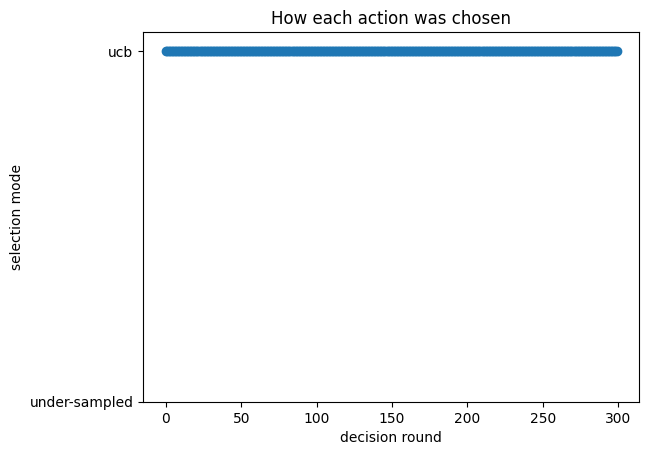

In [5]:
import matplotlib.pyplot as plt

mode_numeric = [0 if rec.mode == "under_sampled" else 1 for rec in learner.decision_history]

plt.plot(mode_numeric, marker="o", linestyle="none")
plt.yticks([0, 1], ["under-sampled", "ucb"])
plt.xlabel("decision round")
plt.ylabel("selection mode")
plt.title("How each action was chosen")
plt.show()

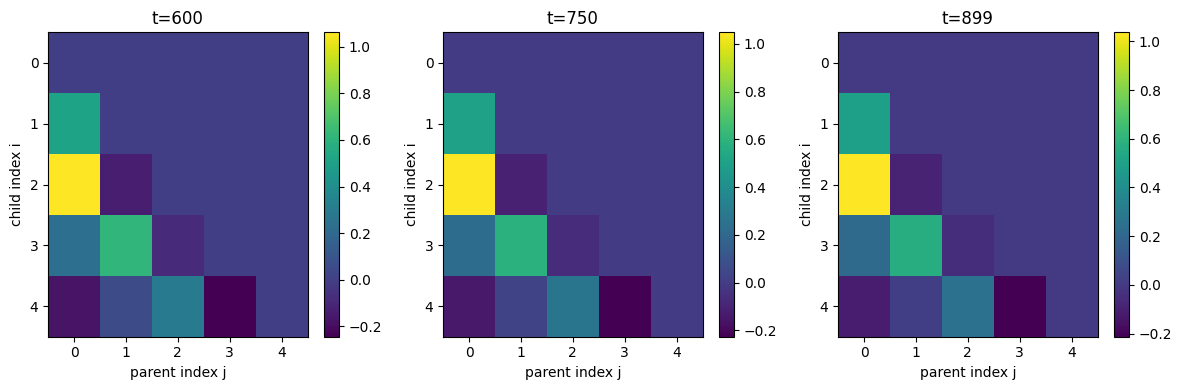

In [5]:
import matplotlib.pyplot as plt
checkpoints = [0, len(learner.A_hat_history)//2, len(learner.A_hat_history)-1]

fig, axes = plt.subplots(1, len(checkpoints), figsize=(4 * len(checkpoints), 4))
if len(checkpoints) == 1:
    axes = [axes]

for ax, k in zip(axes, checkpoints):
    im = ax.imshow(learner.A_hat_history[k], aspect="auto")
    ax.set_title(f"t={learner.round_history[k]}")
    ax.set_xlabel("parent index j")
    ax.set_ylabel("child index i")
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()